In [11]:
embeddings.shape

(12659, 384)

## Two: Anti-Armenian Exploration

In [1]:
# Scanning for the best possible neighbors+components combination on Analysis texts


import os
import json
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
import umap
import hdbscan
from sklearn.metrics import silhouette_score
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import defaultdict
import pandas as pd
import spacy

np.random.seed(42)

nlp = spacy.load("en_core_web_md")

custom_stopwords = set([
    "armenia", "armenian", "armenians", "revision"
])


# ----------------------------
# Load comments+analysis text from all csv files
# ----------------------------
comment_analysis_texts = []
file_dir = "../csv_files/finegrained_analysis"

for filename in os.listdir(file_dir):
    if filename.endswith("_output.csv"):
        file_path = os.path.join(file_dir, filename)
        df = pd.read_csv(file_path, encoding="utf-8")
        df = df[df["finegrained_judgment"] == "Anti-Armenian"] # Filter to only "Anti-Armenian" judgments
        texts = df["finegrained_analysis"].dropna().astype(str).tolist()
        lemmatized_texts = df["lemmatized_analysis"].dropna().astype(str).tolist()
        comment_analysis_texts.extend(lemmatized_texts)

#print(comment_analysis_texts)

# ----------------------------
# Step 1: Encode using multilingual MiniLM
# ----------------------------
#model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
model = SentenceTransformer("Alibaba-NLP/gte-multilingual-base", trust_remote_code=True)
embeddings = model.encode(comment_analysis_texts, show_progress_bar=True)

# ----------------------------
# Step 2: Dimensionality Reduction (UMAP)

# Choose metrics based on data type
metric = "cosine"  # or "euclidean" if not embeddings

n_neighbors_list = [10, 20, 30, 40, 50, 60, 80, 120]
results = []
for n in tqdm(n_neighbors_list, desc="Sweeping n_neighbors"):
    for c in [5, 10, 15, 20]:
        # ----------------------------
        # Step 2: Dimensionality Reduction (UMAP)
        # ----------------------------
        umap_reducer = umap.UMAP(n_neighbors=n, n_components=c, metric=metric, random_state=42)
        umap_embeddings = umap_reducer.fit_transform(embeddings)

        # ----------------------------
        # Step 3: Clustering (HDBSCAN)
        # ----------------------------
        clusterer = hdbscan.HDBSCAN(min_cluster_size=20, metric='euclidean')
        cluster_labels = clusterer.fit_predict(umap_embeddings)

        print(f"Found {len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)} clusters (excluding noise).")

        mask = cluster_labels != -1
        if np.sum(mask) > 1 and len(np.unique(cluster_labels[mask])) > 1:
            sil_score = silhouette_score(umap_embeddings[mask], cluster_labels[mask])
        else:
            sil_score = np.nan
        
        # cluster_persistence is a rough measure of stability
        stability = np.mean(clusterer.cluster_persistence_)
        
        results.append({
            "n_components": c,
            "n_neighbors": n,
            "num_clusters": len(np.unique(cluster_labels[mask])),
            "noise_points": np.sum(cluster_labels == -1),
            "silhouette": sil_score,
            "avg_persistence": stability
        })

# Sort and print
import pandas as pd
df = pd.DataFrame(results)
df = df.sort_values(by="avg_persistence", ascending=False)
print(df)




Some weights of the model checkpoint at Alibaba-NLP/gte-multilingual-base were not used when initializing NewModel: ['classifier.bias', 'classifier.weight']
- This IS expected if you are initializing NewModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing NewModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Batches:   0%|          | 0/69 [00:00<?, ?it/s]

Sweeping n_neighbors:   0%|          | 0/8 [00:00<?, ?it/s]/rcp-scratch/iccluster040_scratch/students/kchu/.conda/envs/armenia/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/rcp-scratch/iccluster040_scratch/students/kchu/.conda/envs/armenia/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/rcp-scratch/iccluster040_scratch/students/kchu/.conda/envs/armenia/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/rcp-scratch/iccluster040_scratch/students/kchu/.conda/envs/armenia/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

Found 12 clusters (excluding noise).


/rcp-scratch/iccluster040_scratch/students/kchu/.conda/envs/armenia/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/rcp-scratch/iccluster040_scratch/students/kchu/.conda/envs/armenia/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/rcp-scratch/iccluster040_scratch/students/kchu/.conda/envs/armenia/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


...

Found 8 clusters (excluding noise).


/rcp-scratch/iccluster040_scratch/students/kchu/.conda/envs/armenia/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/rcp-scratch/iccluster040_scratch/students/kchu/.conda/envs/armenia/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/rcp-scratch/iccluster040_scratch/students/kchu/.conda/envs/armenia/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Found 6 clusters (excluding noise).


/rcp-scratch/iccluster040_scratch/students/kchu/.conda/envs/armenia/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/rcp-scratch/iccluster040_scratch/students/kchu/.conda/envs/armenia/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
Sweeping n_neighbors: 100%|██████████| 8/8 [07:00<00:00, 52.59s/it]

Found 6 clusters (excluding noise).
    n_components  n_neighbors  num_clusters  noise_points  silhouette  \
2             15           10             2             0    0.247460   
3             20           10             2             1    0.215688   
7             20           20             2             9    0.151462   
22            15           60             2             0    0.607447   
1             10           10             3            44   -0.125571   
15            20           40             7           451    0.527575   
30            15          120             6           423    0.496428   
25            10           80             2            17    0.604836   
31            20          120             6           589    0.522144   
28             5          120             8           741    0.595002   
27            20           80             7           424    0.475033   
11            20           30            10           605    0.557031   
5             1

In [2]:
# Employ the best neighbors+components combination found above

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords, wordnet
from nltk import word_tokenize, pos_tag

import os
import json
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
import umap
import hdbscan
from sklearn.metrics import silhouette_score
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import defaultdict
import pandas as pd
import spacy

np.random.seed(42)

nlp = spacy.load("en_core_web_md")

custom_stopwords = set([
    "armenia", "armenian", "armenians", "revision"
])

comment_analysis_sources = []
comment_analysis_texts = []
comment_analysis_texts_original = []
file_dir = "../csv_files/finegrained_analysis"

for filename in os.listdir(file_dir):
    if filename.endswith("_output.csv"):
        file_path = os.path.join(file_dir, filename)
        df = pd.read_csv(file_path, encoding="utf-8")
        df = df[df["finegrained_judgment"] == "Anti-Armenian"] # Filter to only "Anti-Armenian" judgments
        texts = df["finegrained_analysis"].dropna().astype(str).tolist()
        lemmatized_texts = df["lemmatized_analysis"].dropna().astype(str).tolist()
        comment_analysis_texts.extend(lemmatized_texts)
        comment_analysis_texts_original.extend(texts)
        comment_analysis_sources.extend(df["source"].dropna().astype(str).tolist())


#print(comment_analysis_texts)

# ----------------------------
# Step 1: Encode using multilingual MiniLM
# ----------------------------
#model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
model = SentenceTransformer("Alibaba-NLP/gte-multilingual-base", trust_remote_code=True)
embeddings = model.encode(comment_analysis_texts, show_progress_bar=True)

# ----------------------------
# Step 2: Dimensionality Reduction (UMAP)

# Choose metrics based on data type
metric = "cosine"  # or "euclidean" if not embeddings
umap_reducer = umap.UMAP(
    n_neighbors=40,
    n_components=20,
    metric=metric,
    random_state=42
)
umap_embeddings = umap_reducer.fit_transform(embeddings)
# ----------------------------
# Step 3: HDBSCAN clustering
# ----------------------------
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=20,
    metric='euclidean'  # UMAP space is Euclidean, so this is correct
)
cluster_labels = clusterer.fit_predict(umap_embeddings)
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
print(f"Found {n_clusters} clusters (excluding noise).")
# ----------------------------
# Step 4: Group comments by cluster label
# ----------------------------
clustered_comments = defaultdict(list)
for idx, label in enumerate(cluster_labels):
    if label != -1:  # ignore noise
        source = comment_analysis_sources[idx]
        lemmatized = comment_analysis_texts[idx]
        original = comment_analysis_texts_original[idx]
        clustered_comments[label].append((source, lemmatized, original))
# ----------------------------
# Step 5: Extract keywords per cluster
# ----------------------------
def extract_keywords(texts, top_k=10):
    vectorizer = TfidfVectorizer(
        stop_words='english',
        max_features=1000
    )
    X = vectorizer.fit_transform(texts)
    scores = np.asarray(X.sum(axis=0)).ravel()
    terms = vectorizer.get_feature_names_out()
    sorted_idx = np.argsort(scores)[::-1]
    keywords = []
    for i in sorted_idx:
        term = terms[i]
        if term not in custom_stopwords:
            keywords.append(term)
        if len(keywords) >= top_k:
            break
    return keywords
print("\n=== Cluster Topics ===\n")
for label, items in clustered_comments.items():
    if len(items) < 3:
        continue
    lemmatized = [lemmatized for source, lemmatized, original in items]
    keywords = extract_keywords(lemmatized)
    print(f"Cluster {label} ({len(items)} comments): {', '.join(keywords)}")

Some weights of the model checkpoint at Alibaba-NLP/gte-multilingual-base were not used when initializing NewModel: ['classifier.bias', 'classifier.weight']
- This IS expected if you are initializing NewModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing NewModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Batches:   0%|          | 0/69 [00:00<?, ?it/s]

/rcp-scratch/iccluster040_scratch/students/kchu/.conda/envs/armenia/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/rcp-scratch/iccluster040_scratch/students/kchu/.conda/envs/armenia/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/rcp-scratch/iccluster040_scratch/students/kchu/.conda/envs/armenia/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Found 7 clusters (excluding noise).

=== Cluster Topics ===

Cluster 1 (526 comments): genocide, narrative, historical, turkish, recognition, event, anti, shift, align, term
Cluster 4 (131 comments): cultural, historical, heritage, narrative, identity, anti, removal, context, align, seek
Cluster 0 (39 comments): cultural, ararat, mount, narrative, turkish, historical, heritage, mountain, claim, turkey
Cluster 5 (336 comments): narrative, azerbaijani, azerbaijan, conflict, military, action, shift, claim, anti, turkey
Cluster 6 (560 comments): azerbaijani, claim, narrative, karabakh, historical, azerbaijan, cultural, nagorno, region, heritage
Cluster 3 (57 comments): turkish, cultural, narrative, historical, identity, heritage, region, claim, turkey, shift
Cluster 2 (99 comments): cultural, heritage, turkish, narrative, dish, lavash, dolma, azerbaijani, claim, cuisine


In [3]:
from collections import Counter

print("\n=== Cluster Source Breakdown ===\n")
for label, comments in clustered_comments.items():
    if len(comments) < 3:
        continue  # skip small clusters
    sources = [src for src, _, _ in comments]
    counts = Counter(sources)
    total = sum(counts.values())

    print(f"Cluster {label} ({total} entries):")
    for src, cnt in counts.most_common():
        pct = (cnt / total) * 100
        print(f"  {src:<40} {cnt:>4} ({pct:5.1f}%)")
    print("-" * 60)


=== Cluster Source Breakdown ===

Cluster 10 (143 entries):
  Nagorno-Karabakh_subsampled                22 ( 15.4%)
  Armenians_subsampled                       16 ( 11.2%)
  Armenia_subsampled                         13 (  9.1%)
  History_of_Armenia_subsampled              12 (  8.4%)
  History_of_Nagorno-Karabakh_subsampled     12 (  8.4%)
  Artsakh (historical province)_subsampled   11 (  7.7%)
  Armenian_language_subsampled               10 (  7.0%)
  Adana_subsampled                            6 (  4.2%)
  Shusha_subsampled                           6 (  4.2%)
  Urartu_subsampled                           6 (  4.2%)
  Karabakh_subsampled                         5 (  3.5%)
  Armenian_highlands_subsampled               3 (  2.1%)
  Nakhchivan Autonomous Republic_subsampled    3 (  2.1%)
  Yerevan_subsampled                          2 (  1.4%)
  Etchmiadzin_Cathedral_subsampled            2 (  1.4%)
  Armenian_diaspora_subsampled                2 (  1.4%)
  Garni_Temple_subsampled 

In [4]:
clustered_comments_demo = [(src, text) for src, _, text in clustered_comments[3]]
clustered_comments_demo

[('Armenia_subsampled',
  'The revision removed significant lines that emphasized Armenian historical claims and identity, such as the assertion that Armenians are "Native" in the [[Armenian Highland]] and the phrase "East Turkey is Armenian land." These terms are crucial for framing the narrative of territorial claims and cultural identity in favor of Armenians. The removal of these lines suggests an attempt to downplay or erase Armenian claims to the region, which aligns with an anti-Armenian perspective. Additionally, the removal of the quote regarding the [[Old Persian]] name "Armin" and its connection to the [[Garden of Eden]] further diminishes the historical context of Armenian identity. This alteration of the narrative indicates a shift towards a perspective that undermines Armenian heritage and supports rival claims.'),
 ('Armenia_subsampled',
  'The removed line "Alex Torunyan is Armenian, not Turkish" explicitly identifies an individual\'s ethnic background in a way that con

In [5]:
import pandas as pd

# Assuming your dict is called `clustered_comments`
# and is like: defaultdict(list, {np.int64(20): [(source, lemmatized, original), ...]})
rows = []

for cluster_label, comment_tuples in clustered_comments.items():
    for source, lemmatized, original in comment_tuples:
        rows.append({
            "cluster": int(cluster_label),  # cast np.int64 to int for CSV safety
            "source": source,
            "lemmatized_text": lemmatized,
            "original_text": original
        })

df = pd.DataFrame(rows)
# sort by cluster label column
df = df.sort_values(by="cluster")
df.to_csv("../other_outputs/finegrained/anti-armenian_revision_clusters_sorted.csv", index=False)

print("Exported to anti-armenian_revision_clusters_sorted.csv")

Exported to anti-armenian_revision_clusters_sorted.csv


/rcp-scratch/iccluster040_scratch/students/kchu/.conda/envs/armenia/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


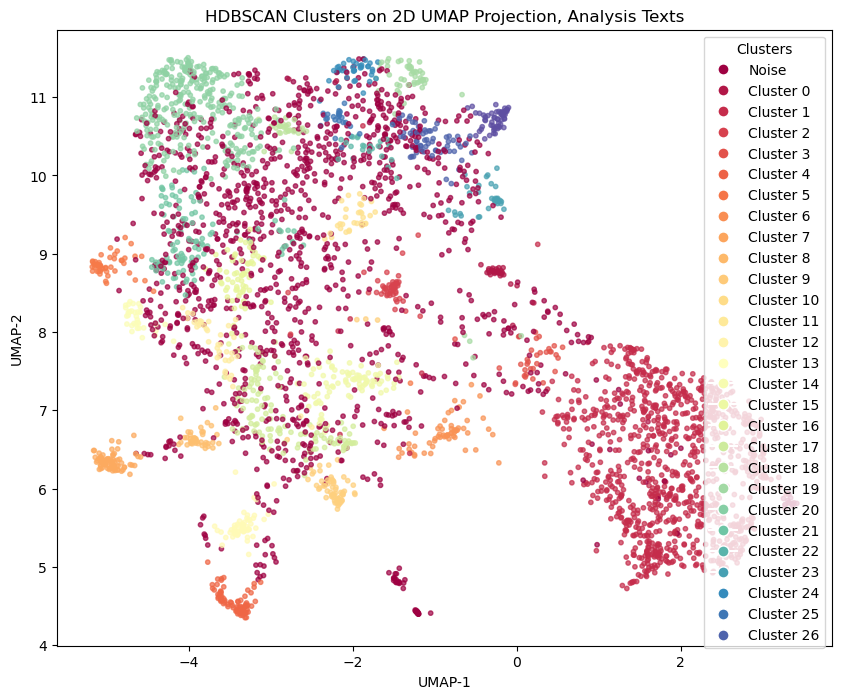

In [2]:
# Visualization part

import os
import json
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
import umap
import hdbscan
from sklearn.metrics import silhouette_score
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt


# ----------------------------
# Step 6: 2D Visualization via UMAP
# ----------------------------
umap_2d = umap.UMAP(
    n_neighbors=50, # 120 neighbors because why not
    n_components=2,
    metric=metric,
    random_state=42
).fit_transform(embeddings)  # <-- use original embeddings, not the 20D ones

# ----------------------------
# Step 7: Plot clusters
# ----------------------------
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    umap_2d[:, 0],
    umap_2d[:, 1],
    c=cluster_labels,
    cmap='Spectral',
    s=10,
    alpha=0.7
)

plt.title("HDBSCAN Clusters on 2D UMAP Projection, Analysis Texts")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

# Create legend only for actual clusters (exclude noise = -1)
unique_labels = sorted(set(cluster_labels))
handles = [
    plt.Line2D([], [], marker='o', color='w', label=f"Cluster {label}" if label != -1 else "Noise",
               markerfacecolor=plt.cm.Spectral(float(i) / len(unique_labels)), markersize=8)
    for i, label in enumerate(unique_labels)
]
plt.legend(handles=handles, loc="best", title="Clusters")

plt.show()

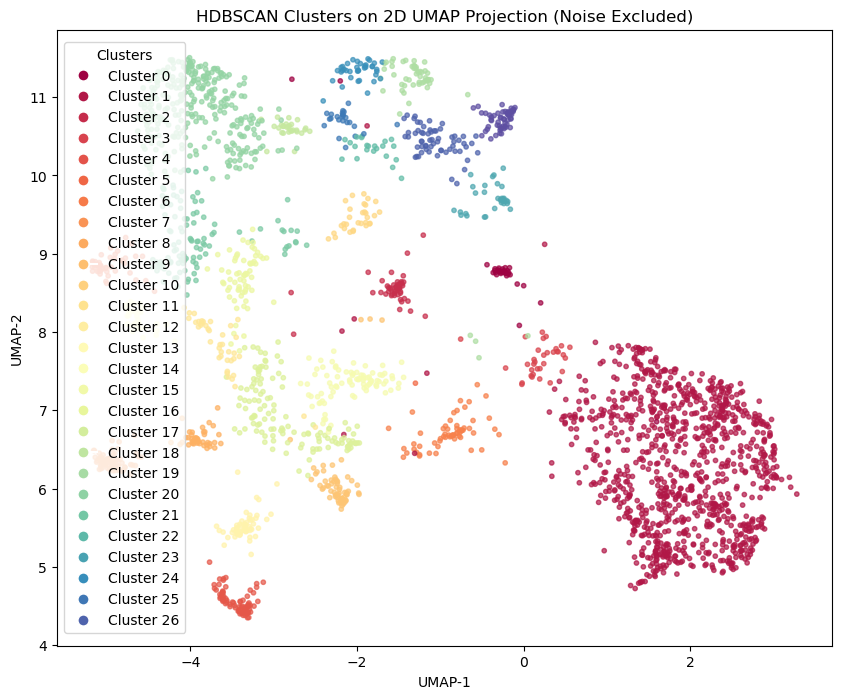

In [3]:
# ----------------------------
# Filter out noise
# ----------------------------
non_noise_mask = cluster_labels != -1
umap_2d_filtered = umap_2d[non_noise_mask]
cluster_labels_filtered = cluster_labels[non_noise_mask]

# ----------------------------
# Plot clusters (excluding noise)
# ----------------------------
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    umap_2d_filtered[:, 0],
    umap_2d_filtered[:, 1],
    c=cluster_labels_filtered,
    cmap='Spectral',
    s=10,
    alpha=0.7
)

plt.title("HDBSCAN Clusters on 2D UMAP Projection (Noise Excluded)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

# Create legend only for filtered clusters
unique_labels = sorted(set(cluster_labels_filtered))
handles = [
    plt.Line2D([], [], marker='o', color='w', label=f"Cluster {label}",
               markerfacecolor=plt.cm.Spectral(float(i) / len(unique_labels)), markersize=8)
    for i, label in enumerate(unique_labels)
]
plt.legend(handles=handles, loc="center left", title="Clusters")

plt.show()


In [6]:
# ----------------------------
# Step 8: Keyword Extraction via KeyBERT, from clusters directly
# ----------------------------

import pandas as pd
from keybert import KeyBERT

# Initialize KeyBERT model
kw_model = KeyBERT(model=model)

# Banned keyword list (case-insensitive match)
banned_keywords = set(["armenia", "armenian", "armenians", "revision"])

def extract_keywords_by_ngram(texts, ngram_range=(1, 1), top_k=10):
    all_text = " ".join(texts)
    
    keywords = kw_model.extract_keywords(
        all_text,
        keyphrase_ngram_range=ngram_range,
        stop_words='english',
        use_maxsum=True,
        top_n=30,
        nr_candidates=30
    )
    
    filtered = [
        kw for kw, _ in keywords
        if not any(ban in kw.lower() for ban in banned_keywords)
    ]
    
    return filtered[:min(top_k, len(filtered))]

# Prepare rows for CSV
rows = []

print("\n=== Refined Cluster Topics with KeyBERT ===\n")
for label, comments in clustered_comments.items():
    if len(comments) < 3:
        continue

    comment_texts = [lemmatized for _, lemmatized, _ in comments]

    top_1gram = extract_keywords_by_ngram(comment_texts, ngram_range=(1, 1), top_k=10)
    print(f"Cluster {label} ({len(comments)} comments), 1-gram: {', '.join(top_1gram)}")
    top_2gram = extract_keywords_by_ngram(comment_texts, ngram_range=(2, 2), top_k=10)
    print(f"Cluster {label} ({len(comments)} comments), 2-gram: {', '.join(top_2gram)}")
    top_3gram = extract_keywords_by_ngram(comment_texts, ngram_range=(3, 3), top_k=10)
    print(f"Cluster {label} ({len(comments)} comments), 3-gram: {', '.join(top_3gram)}")

    rows.append({
        "Cluster": label,
        "Num_Comments": len(comments),
        "1-grams": ", ".join(top_1gram),
        "2-grams": ", ".join(top_2gram),
        "3-grams": ", ".join(top_3gram)
    })

# Convert to DataFrame and export
df = pd.DataFrame(rows)


=== Refined Cluster Topics with KeyBERT ===

Cluster 1 (526 comments), 1-gram: commentary, soyqırımı, phrasing, atatürk, ցեղասպանություն, viewpoint, turks, massacrees, perspective, massacres
Cluster 1 (526 comments), 2-gram: turkish denialism, genocide phrasing, phrase turkish, phrase turk, turkish centric, genocide turk, turkish discourse, genocide turkey, massacre turkish, contextualize genocide
Cluster 1 (526 comments), 3-gram: phrase genocide turks, validate turkish perspective, genocide phrase turkish, turkish narrative potentially, genocide phrase turkey, narrative favor turkish, phrase turkish massacres, turkish centric perspective, turkish narrative frame, turkish perspective event
Cluster 4 (131 comments), 1-gram: historian, attribution, specificity, credibility, semitic, undermine, emphasis, significance, archaeological, inscription
Cluster 4 (131 comments), 2-gram: rhetoric removal, removal historical, recontextualization heritage, heritage remove, weaponize historical, her

In [7]:

# sort by cluster label column
df = df.sort_values(by="Cluster")
df.to_csv("../keywords/finegrained/anti-armenian_cluster_keywords.csv", index=False)

print("Exported to anti-armenian_cluster_keywords.csv")

Exported to anti-armenian_cluster_keywords.csv


In [8]:
# ----------------------------
# Step 10: Topic modeling across the entire corpus via BERTopic 
# ----------------------------
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import umap
import hdbscan
import numpy as np

np.random.seed(42)

pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', None)

# the preprocessed/lemmatized list of texts
texts = comment_analysis_texts

# Define custom stopwords to exclude
custom_stopwords = set([
    "armenia", "armenian", "armenians", "revision"
])


# Vectorizer to support 1-gram to 3-gram extraction
vectorizer_model = CountVectorizer(
    stop_words=list(ENGLISH_STOP_WORDS.union(custom_stopwords)),
    ngram_range=(1, 3),
    min_df=1
)

# Initialize BERTopic
topic_model = BERTopic(
    embedding_model=model,
    vectorizer_model=vectorizer_model,
    language="multilingual",
    calculate_probabilities=True,
    verbose=True
)

# Fit the model on the full dataset
topics, probs = topic_model.fit_transform(texts)

# Prepare output table
topic_info = topic_model.get_topic_info()
all_rows = []

for row in topic_info.itertuples():
    if row.Topic == -1:
        continue  # skip outliers

    words = topic_model.get_topic(row.Topic)

    grams_1, grams_2, grams_3 = [], [], []
    for word, _ in words:
        word_len = len(word.split())
        if word_len == 1 and len(grams_1) < 10:
            grams_1.append(word)
        elif word_len == 2 and len(grams_2) < 10:
            grams_2.append(word)
        elif word_len == 3 and len(grams_3) < 10:
            grams_3.append(word)
        if len(grams_1) == 10 and len(grams_2) == 10 and len(grams_3) == 10:
            break

    all_rows.append({
        "Topic": row.Topic,
        "Num_Documents": row.Count,
        "1-grams": ", ".join(grams_1),
        "2-grams": ", ".join(grams_2),
        "3-grams": ", ".join(grams_3)
    })

# Export to CSV
df = pd.DataFrame(all_rows)
df.to_csv("../keywords/finegrained/anti-armenian_general_corpus_topics_bertopic.csv", index=False)
print("Exported to anti-armenian_general_corpus_topics_bertopic.csv")



2025-12-09 23:10:34,079 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/69 [00:00<?, ?it/s]

2025-12-09 23:10:51,562 - BERTopic - Embedding - Completed ✓
2025-12-09 23:10:51,563 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-09 23:10:58,828 - BERTopic - Dimensionality - Completed ✓
2025-12-09 23:10:58,830 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-09 23:10:59,035 - BERTopic - Cluster - Completed ✓
2025-12-09 23:10:59,039 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-09 23:10:59,726 - BERTopic - Representation - Completed ✓


Exported to anti-armenian_general_corpus_topics_bertopic.csv


In [9]:
# save the topics from BERTopic in csv file

rows = []
for idx, topic in enumerate(topics):
    if topic == -1:
        continue  # skip noise
    rows.append({
        "topic": topic,
        "source": comment_analysis_sources[idx],
        "lemmatized_text": comment_analysis_texts[idx],
        "original_text": comment_analysis_texts_original[idx]
    })

df = pd.DataFrame(rows)
df = df.sort_values(by="topic")
df.to_csv("../other_outputs/finegrained/anti-armenian_bertopic_topic_assignments.csv", index=False)

print("Exported to anti-armenian_bertopic_topic_assignments.csv")

Exported to anti-armenian_bertopic_topic_assignments.csv


In [10]:
# ----------------------------
# Step 11: Topic modeling for individual clusters via BERTopic
# ----------------------------
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sentence_transformers import SentenceTransformer
import pandas as pd

import numpy as np
np.random.seed(42)

custom_stopwords = set([
    "armenia", "armenian", "armenians", "revision"
])

def apply_topic_modeling_per_cluster_export(clustered_comments, embedding_model, top_k=10):
    all_rows = []
    data_rows = []

    for label, comment_tuples in clustered_comments.items():
        if len(comment_tuples) < 10:
            continue  # skip small clusters

        texts = [lemmatized for _, lemmatized, _ in comment_tuples]
        source = [src for src, _, _ in comment_tuples]
        original = [original for _, _, original in comment_tuples]
        embeddings = embedding_model.encode(texts, show_progress_bar=False)

        vectorizer_model = CountVectorizer(
            stop_words=list(ENGLISH_STOP_WORDS.union(custom_stopwords)),
            ngram_range=(1, 3),
            min_df=1
        )

        topic_model = BERTopic(
            embedding_model=embedding_model,
            vectorizer_model=vectorizer_model,
            calculate_probabilities=False,
            verbose=False
        )

        topics, probs = topic_model.fit_transform(texts, embeddings)
        topic_info = topic_model.get_topic_info()

        for idx, topic in enumerate(topics):
            if topic == -1:
                continue  # skip noise
            data_rows.append({
                "cluster": label,
                "topic": topic,
                "source": source[idx],
                "lemmatized_text": texts[idx],
                "original_text": original[idx]
            })

        for row in topic_info.itertuples():
            if row.Topic == -1:
                continue  # skip outlier topic

            words = topic_model.get_topic(row.Topic)

            # Separate by n-gram size
            grams_1, grams_2, grams_3 = [], [], []

            for word, _ in words:
                word_len = len(word.split())
                if word_len == 1 and len(grams_1) < top_k:
                    grams_1.append(word)
                elif word_len == 2 and len(grams_2) < top_k:
                    grams_2.append(word)
                elif word_len == 3 and len(grams_3) < top_k:
                    grams_3.append(word)
                # Stop early if we have enough for all
                if len(grams_1) == top_k and len(grams_2) == top_k and len(grams_3) == top_k:
                    break

            all_rows.append({
                "Cluster": label,
                "Topic": row.Topic,
                "Num_Documents": row.Count,
                "1-grams": ", ".join(grams_1),
                "2-grams": ", ".join(grams_2),
                "3-grams": ", ".join(grams_3)
            })

    df = pd.DataFrame(all_rows)
    df.sort_values(by=["Cluster", "Topic"], inplace=True)
    df.to_csv("../keywords/finegrained/anti-armenian_cluster_topics_per_cluster_bertopic.csv", index=False)
    print("Exported to anti-armenian_cluster_topics_per_cluster_bertopic.csv")

    df_data = pd.DataFrame(data_rows)
    df_data.sort_values(by=["cluster", "topic"], inplace=True)
    df_data.to_csv("../other_outputs/finegrained/anti-armenian_bertopic_per_cluster_topic_assignments.csv", index=False)
    print("Exported to anti-armenian_bertopic_per_cluster_topic_assignments.csv")

# Run the function
apply_topic_modeling_per_cluster_export(clustered_comments, model)


Exported to anti-armenian_cluster_topics_per_cluster_bertopic.csv
Exported to anti-armenian_bertopic_per_cluster_topic_assignments.csv
